In [695]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [696]:
df = pd.read_csv("/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/Cancer_data.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [697]:
df.drop(['Unnamed: 32', 'id'], axis = 1, inplace = True)

# checking for missing values
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [698]:
df.dtypes

diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

In [699]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


<Axes: >

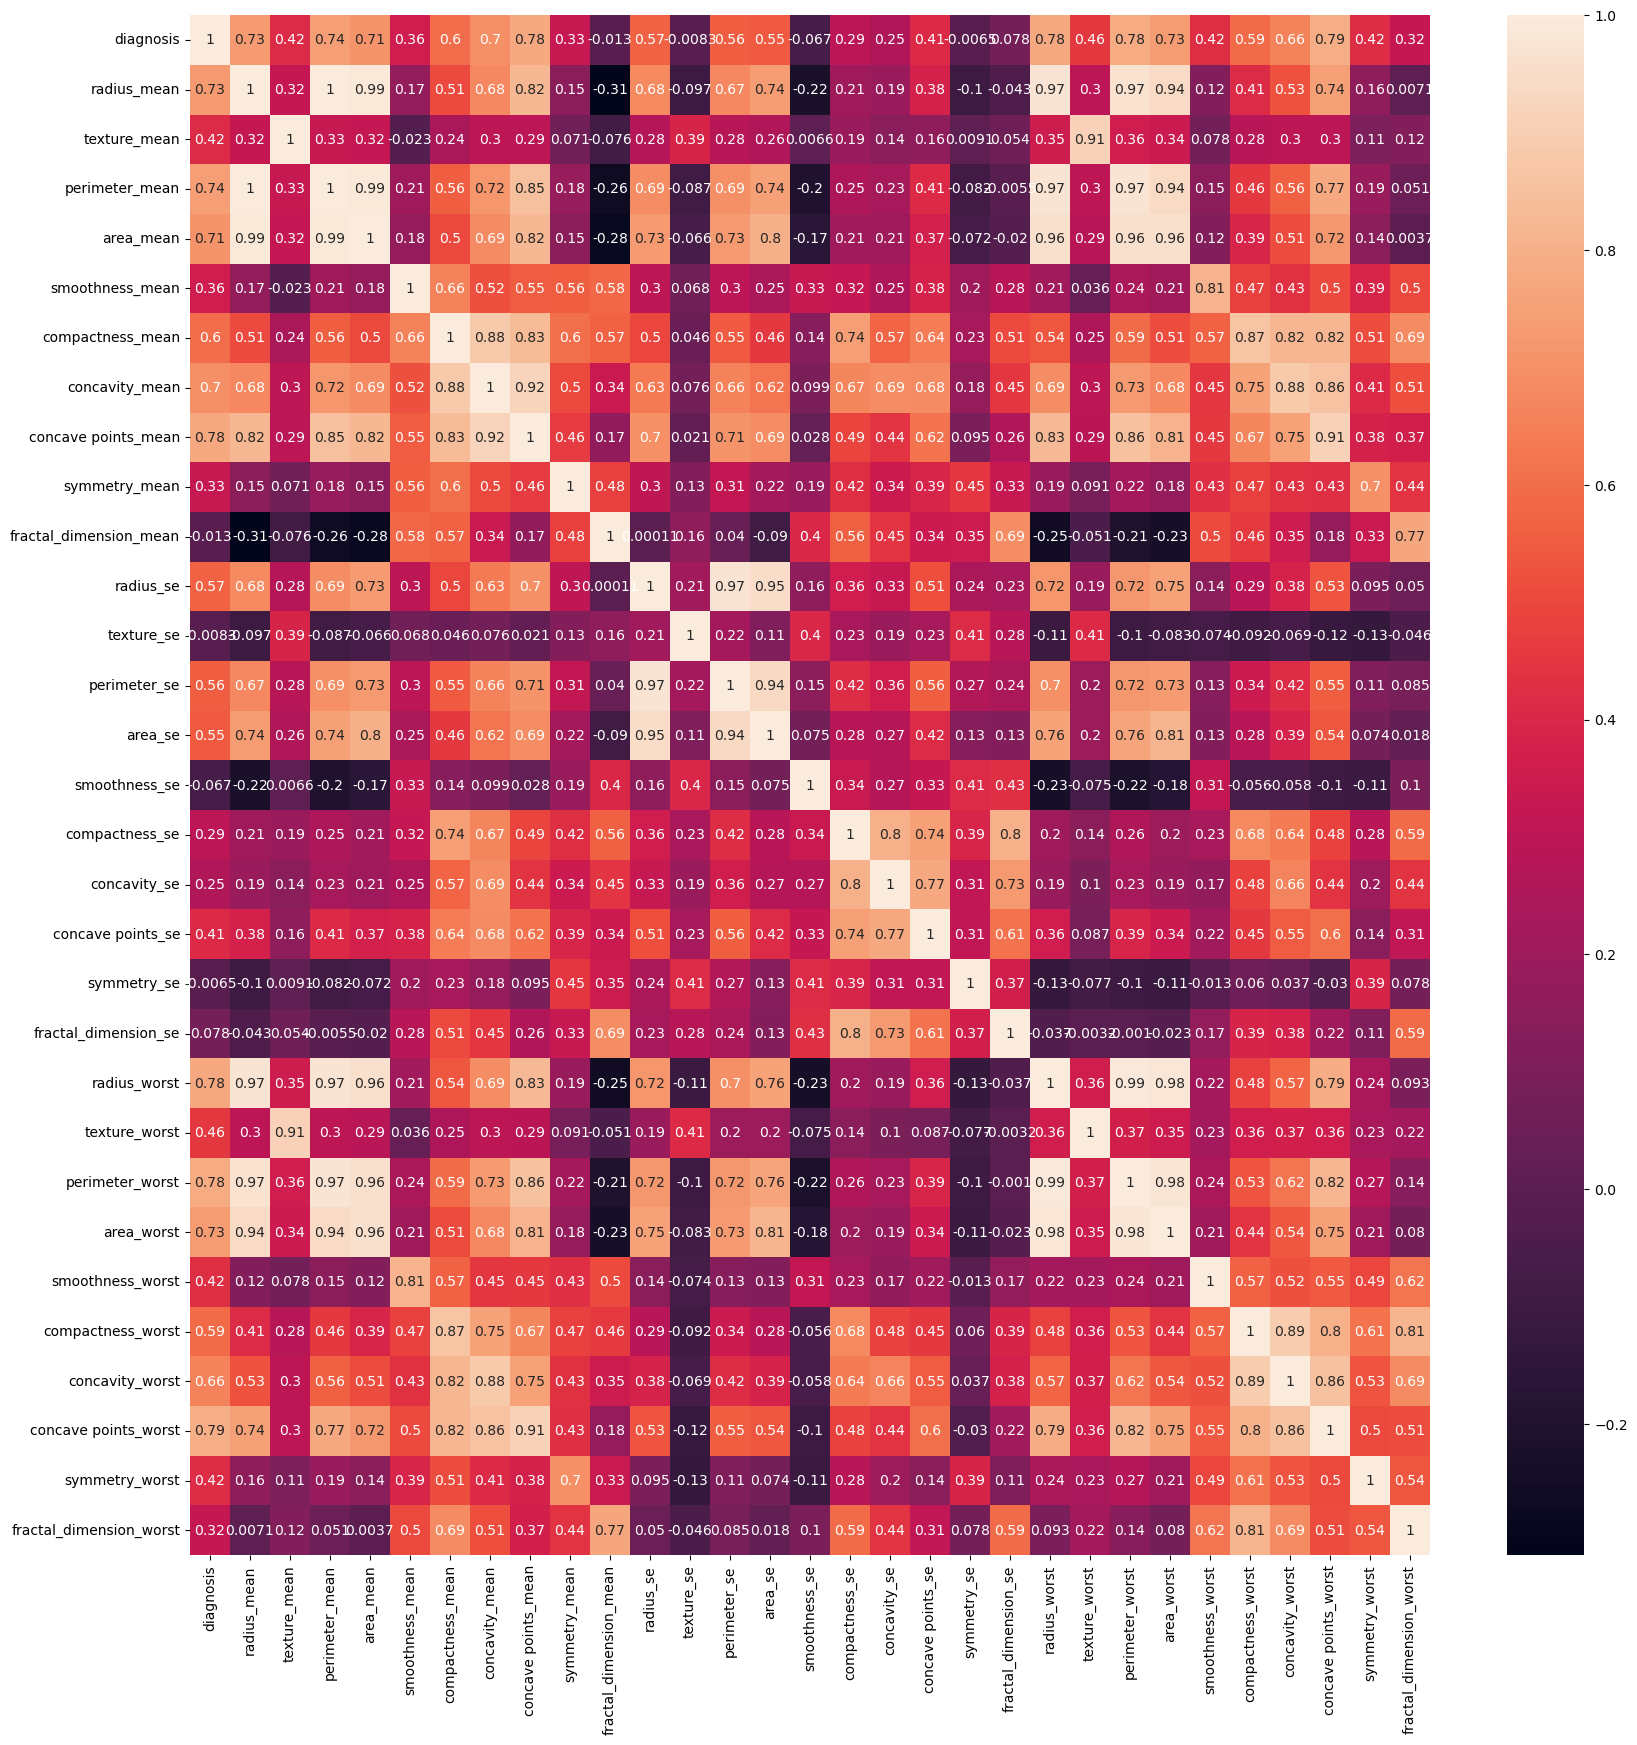

In [700]:
# correlation between the columns diagnosis and other columns
# Binary encoding since corr() only works with numerical values
df['diagnosis'] = df['diagnosis'].map({'M' : 1, 'B' : 0})

plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot = True)

In [701]:
corr = df.corr()
corr[abs(corr['diagnosis']) > 0.59].index

Index(['diagnosis', 'radius_mean', 'perimeter_mean', 'area_mean',
       'compactness_mean', 'concavity_mean', 'concave points_mean',
       'radius_worst', 'perimeter_worst', 'area_worst', 'compactness_worst',
       'concavity_worst', 'concave points_worst'],
      dtype='object')

### Interpretation 

#### The following columns are the one's that show the greatest correlation with our diagnosis column. There are two things that can be done. We can either use only the columns which have greatest correlation, or we can continue to use all the columns. For this project, we will be using all these columns to predict our result

<Axes: >

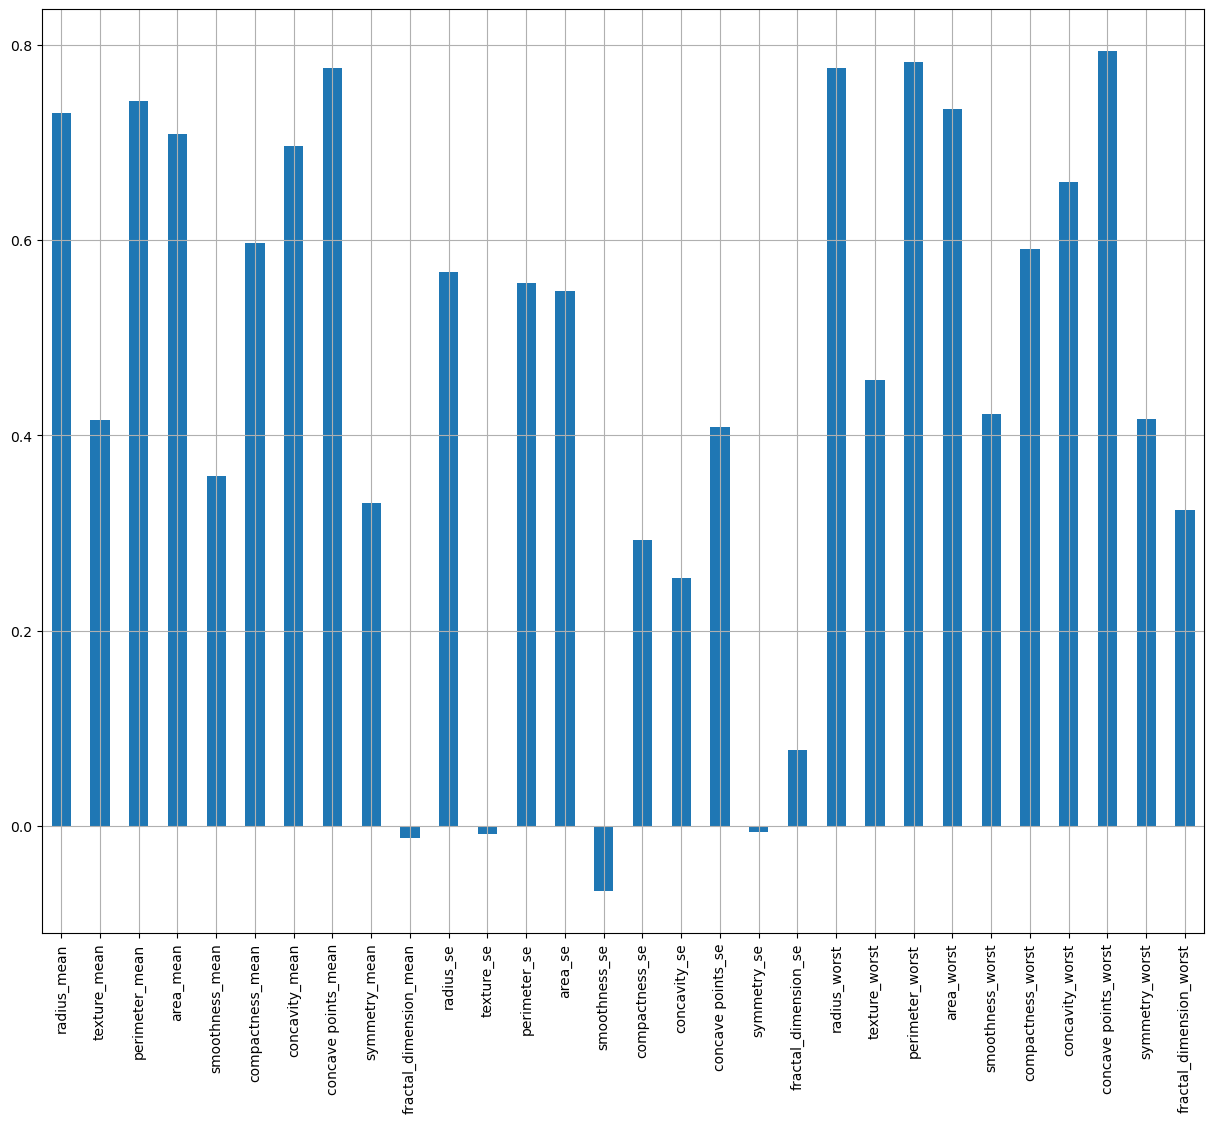

In [702]:
df.drop('diagnosis', axis =1).corrwith(df['diagnosis']).plot(kind="bar", figsize = (15, 12), grid = True)

### Determining the Outliers using the Local Outlier Factor

In [703]:
from sklearn.neighbors import LocalOutlierFactor

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]  

columns = df.columns.tolist

lof = LocalOutlierFactor()
y_pred = lof.fit_predict(X)
y_pred[:20]

# - 1 --> outlier 
# 1 --> not an outlier

array([ 1,  1,  1, -1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1])

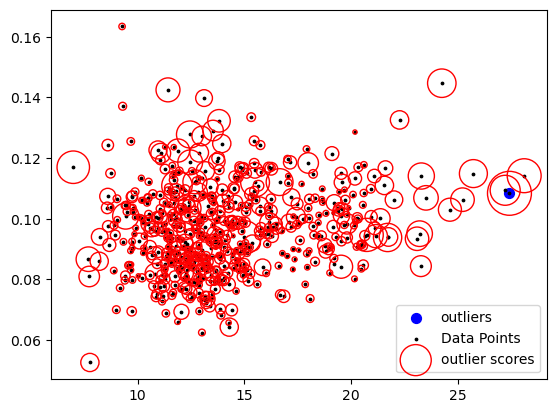

In [704]:
# get raw LOF score
x_score = lof.negative_outlier_factor_

outlier_score = pd.DataFrame()
outlier_score["score"] = x_score

threshold = -2.5 # anything with a score of > - 2.5 will be considered an outlier

filter = outlier_score['score'] < threshold
outlier_index = outlier_score[filter].index.tolist()

plt.scatter(X.iloc[outlier_index, 0], X.iloc[outlier_index, 4], color="blue", s=50, label="outliers")
plt.scatter(X.iloc[:,0], X.iloc[:,4], color="k", s=3, label="Data Points")

radius = (x_score.max() - x_score) / (x_score.max() - x_score.min())

plt.scatter(X.iloc[:,0], X.iloc[:,4],
            s=1000 * radius,
            edgecolors="r",
            facecolors="none",
            label="outlier scores")

plt.legend()
plt.show()


In [705]:
X = X.drop(outlier_index)
y = y.drop(outlier_index)


In [706]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [707]:
key = ['LogisticRegression', 'DeicisionTreeClassifier', 'RandomForestClassifier', 'GradientBoostingClassifier']
value = [LogisticRegression(), DecisionTreeClassifier(random_state=10), RandomForestClassifier(n_estimators = 60, random_state = 0), GradientBoostingClassifier(random_state=20)]

models = dict(zip(key, value))
models

{'LogisticRegression': LogisticRegression(),
 'DeicisionTreeClassifier': DecisionTreeClassifier(random_state=10),
 'RandomForestClassifier': RandomForestClassifier(n_estimators=60, random_state=0),
 'GradientBoostingClassifier': GradientBoostingClassifier(random_state=20)}

In [708]:
res = []
for name, algo in models.items():
    model = algo
    model.fit(X_train, y_train)
    predict = model.predict(X_test)
    acc = accuracy_score(y_test, predict)
    res.append(acc)
    print(name, acc)

LogisticRegression 0.9649122807017544
DeicisionTreeClassifier 0.9035087719298246
RandomForestClassifier 0.956140350877193
GradientBoostingClassifier 0.956140350877193


### Checking if any of the top performing models can be improved in our prediction

### Logistic Regression

In [709]:
lr = LogisticRegression(solver = 'lbfgs', max_iter = 10000)

rs = []
acc = []

for i in range(1, 25, 1):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= i)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    model = lr.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc.append(accuracy_score(y_test, pred))
    rs.append(i)

0.9649122807017544
0.9649122807017544
0.9736842105263158
0.9649122807017544
0.9736842105263158
0.9824561403508771
0.9649122807017544
0.9649122807017544
0.9824561403508771
0.9649122807017544
0.9649122807017544
0.9824561403508771
0.9824561403508771
0.9912280701754386
0.9649122807017544
0.956140350877193
0.9736842105263158
0.9824561403508771
0.9912280701754386
1.0
1.0
0.9736842105263158
0.9912280701754386
0.9824561403508771


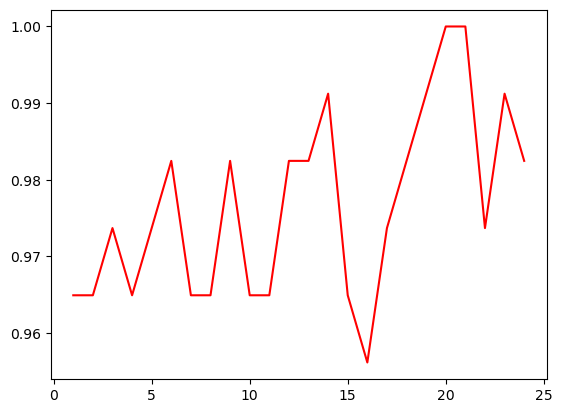

In [710]:
plt.plot(rs, acc, color = 'red')

for i in range(0,24):
    print(acc[i])

### Gradient Boosting

In [711]:
gd = GradientBoostingClassifier(n_estimators = 62)

res = []
acc2 = []

for i in range(1, 25, 1):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= i)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    model = gd.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc2.append(accuracy_score(y_test, pred))
    res.append(i)

1 0.9385964912280702
2 0.9298245614035088
3 0.9210526315789473
4 0.9298245614035088
5 0.9649122807017544
6 0.9298245614035088
7 0.9473684210526315
8 0.956140350877193
9 0.956140350877193
10 0.956140350877193
11 0.9385964912280702
12 0.9473684210526315
13 0.9473684210526315
14 0.956140350877193
15 0.9035087719298246
16 0.9736842105263158
17 0.9649122807017544
18 0.9385964912280702
19 0.9473684210526315
20 0.9824561403508771
21 0.9824561403508771
22 0.9473684210526315
23 0.956140350877193
24 0.956140350877193


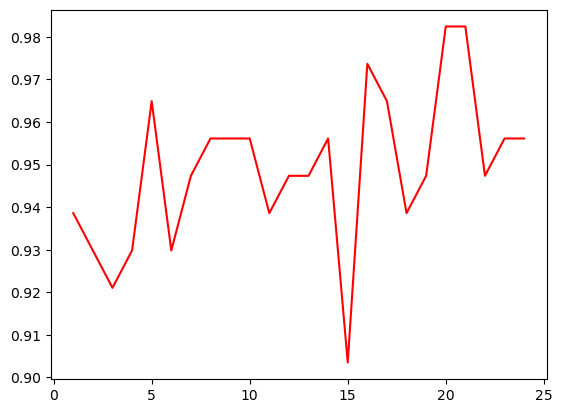

In [712]:
for i in range(len(res)):
    print(res[i], acc2[i])
    
plt.plot(res, acc2, color = 'red')
plt.show()

### Random Forest

In [713]:
rf = RandomForestClassifier()

ans = []
acc3 = []

for i in range(1, 25, 1):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=10)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    model = rf.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc3.append(accuracy_score(y_test, pred))
    ans.append(i)

1 0.9824561403508771
2 0.9766081871345029
3 0.9766081871345029
4 0.9707602339181286
5 0.9766081871345029
6 0.9766081871345029
7 0.9824561403508771
8 0.9707602339181286
9 0.9766081871345029
10 0.9707602339181286
11 0.9766081871345029
12 0.9766081871345029
13 0.9766081871345029
14 0.9766081871345029
15 0.9766081871345029
16 0.9707602339181286
17 0.9766081871345029
18 0.9766081871345029
19 0.9707602339181286
20 0.9766081871345029
21 0.9766081871345029
22 0.9766081871345029
23 0.9707602339181286
24 0.9766081871345029


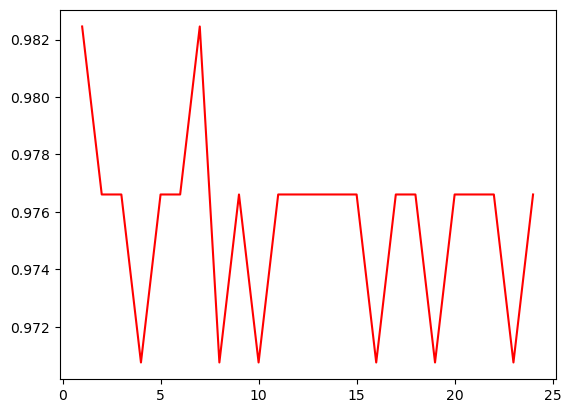

In [714]:
for i in range(len(ans)):
    print(ans[i], acc3[i])
    
plt.plot(ans, acc3, color = 'red')
plt.show()

In [715]:
print("Mean accuracy for Logistic Regression: ", np.mean(acc))
print("Std deviation for Logistic Regression :", np.std(acc))
print("Mean accuracy for Gradient Boosting: ", np.mean(acc2))
print("Std deviation for Gradient Boosting: ", np.std(acc2))
print("Mean accuracy for Random Forest: ", np.mean(acc3))
print("Std deviation for Random Forest: ", np.std(acc3))

Mean accuracy for Logistic Regression:  0.9766081871345028
Std deviation for Logistic Regression : 0.01205586440239081
Mean accuracy for Gradient Boosting:  0.9488304093567251
Std deviation for Gradient Boosting:  0.018201607599398716
Mean accuracy for Random Forest:  0.9756335282651071
Std deviation for Random Forest:  0.0032325777683775937


### Three models were evaluated across 24 randomized train-test splits. Logistic Regression achieved the highest average accuracy (97.66%), while Random Forest demonstrated the lowest variance (σ = 0.0032), indicating superior stability. Gradient Boosting underperformed, suggesting the dataset favors simpler models with linear decision boundaries.
